<a href="https://colab.research.google.com/github/alumoluyasasweereddy-a/PEC_Connect_Capstone/blob/main/retail_sale_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import scipy as stats
df=pd.read_csv(r"C:\Users\Alumo\Downloads\retail_sales_dataset (1).csv")
print(df)
print(df.head())
print(df.info())
print(df.tail)
print(df.describe)

median_steps=df['Total Amount'].median()
df['Group']=np.where(df['Total Amount'] >= median_steps,'High Activity','Low Activity')
group_high=df[df['Group']=='High Activity']['Gender']
group_low=df[df['Group']=='Low Activiy']['Gender']

group_high=df[df['Group']=='High Activity']['Age']
group_low=df[df['Group']=='Low Activiy']['Age']
print(group_high)
print(group_low)
df[['Total Amount','Gender']].value_counts
t_stat,p_value=stats.ttest_ind(group_high,group_low,equal_var=False)
print('T-statistic:',t_stat)
print('P-value:',p_value)

     Transaction ID        Date Customer ID  Gender  Age Product Category  \
0                 1  2023-11-24     CUST001    Male   34           Beauty   
1                 2  2023-02-27     CUST002  Female   26         Clothing   
2                 3  2023-01-13     CUST003    Male   50      Electronics   
3                 4  2023-05-21     CUST004    Male   37         Clothing   
4                 5  2023-05-06     CUST005    Male   30           Beauty   
..              ...         ...         ...     ...  ...              ...   
995             996  2023-05-16     CUST996    Male   62         Clothing   
996             997  2023-11-17     CUST997    Male   52           Beauty   
997             998  2023-10-29     CUST998  Female   23           Beauty   
998             999  2023-12-05     CUST999  Female   36      Electronics   
999            1000  2023-04-12    CUST1000    Male   47      Electronics   

     Quantity  Price per Unit  Total Amount  
0           3              50

AttributeError: Module 'scipy' has no attribute 'ttest_ind'

In [ ]:
from scipy import stats

t_stat, p_value = stats.ttest_ind(group_high, group_low, equal_var=False)

print("T-statistic:", t_stat)
print("P-value:", p_value)



T-statistic: nan
P-value: nan


C:\Users\Alumo\anaconda3\envs\py12\Lib\site-packages\scipy\_lib\deprecation.py:234: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  return f(*args, **kwargs)


In [ ]:
alpha=0.05
if p_value< alpha:
    print('reject the null hypothesis :')
else:
    print('fail to reject the hypothesis:')



fail to reject the hypothesis:


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['gender_encoded'] = le.fit_transform(df['Gender'])

print(df[['Gender', 'gender_encoded']])
print("Classes:", le.classes_)


     Gender  gender_encoded
0      Male               1
1    Female               0
2      Male               1
3      Male               1
4      Male               1
..      ...             ...
995    Male               1
996    Male               1
997  Female               0
998  Female               0
999    Male               1

[1000 rows x 2 columns]
Classes: ['Female' 'Male']


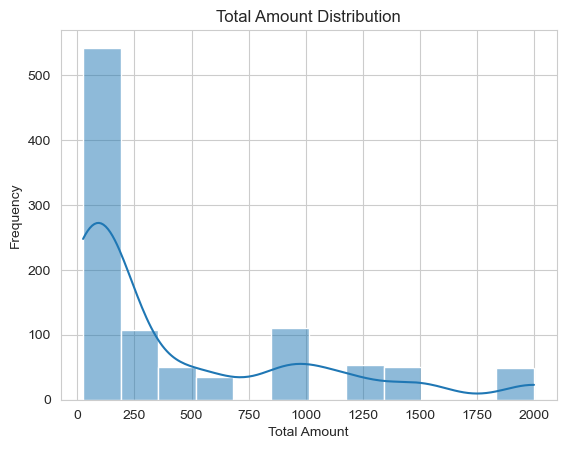

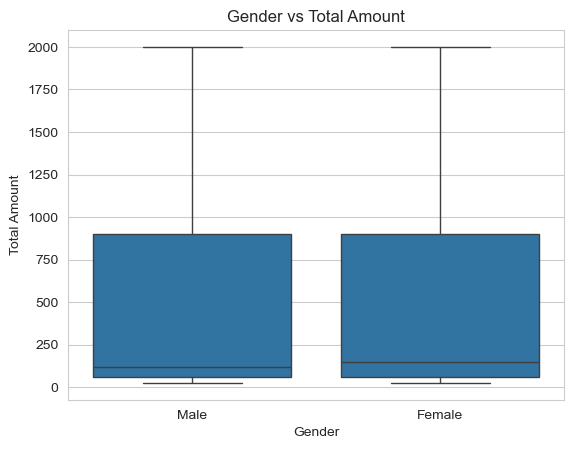

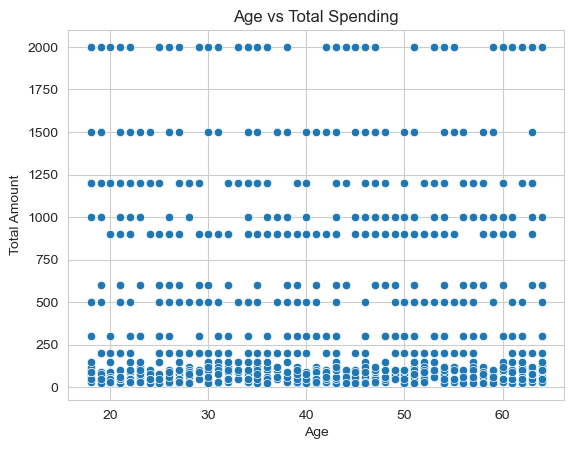

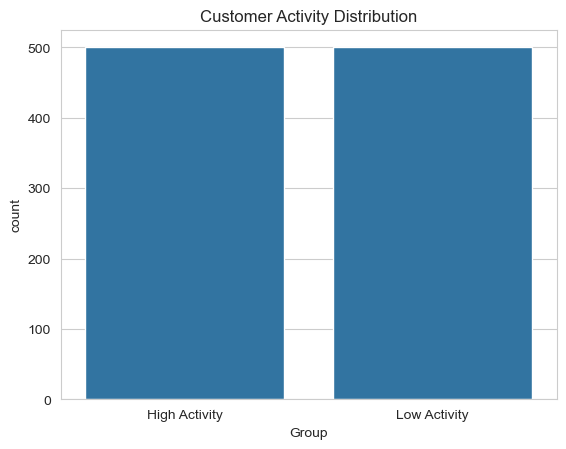

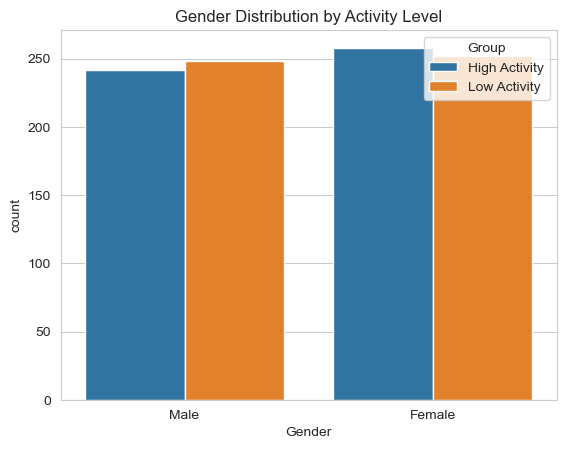

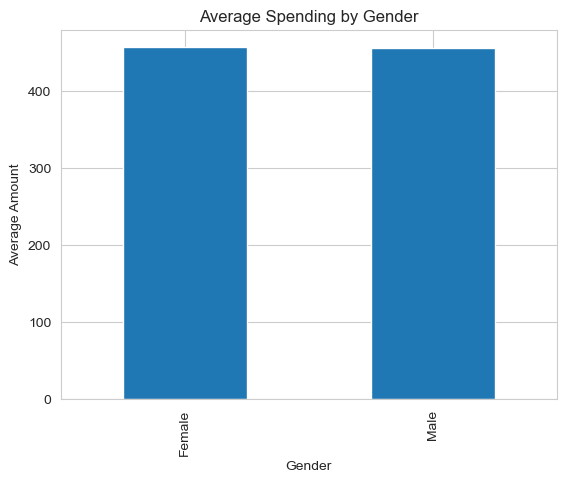

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# set style (optional but looks better)
sns.set_style("whitegrid")


# -------------------------
# 1. Total Amount Distribution
# -------------------------
plt.figure()
sns.histplot(df['Total Amount'], kde=True)
plt.title("Total Amount Distribution")
plt.xlabel("Total Amount")
plt.ylabel("Frequency")
plt.show()


# -------------------------
# 2. Gender vs Total Amount
# -------------------------
plt.figure()
sns.boxplot(x='Gender', y='Total Amount', data=df)
plt.title("Gender vs Total Amount")
plt.show()


# -------------------------
# 3. Age vs Total Amount
# -------------------------
plt.figure()
sns.scatterplot(x='Age', y='Total Amount', data=df)
plt.title("Age vs Total Spending")
plt.show()


# -------------------------
# 4. High vs Low Activity (your grouping)
# -------------------------
plt.figure()
sns.countplot(x='Group', data=df)
plt.title("Customer Activity Distribution")
plt.show()


# -------------------------
# 5. Gender distribution in groups
# -------------------------
plt.figure()
sns.countplot(x='Gender', hue='Group', data=df)
plt.title("Gender Distribution by Activity Level")
plt.show()


# -------------------------
# 6. Average spending by gender
# -------------------------
plt.figure()
df.groupby('Gender')['Total Amount'].mean().plot(kind='bar')
plt.title("Average Spending by Gender")
plt.ylabel("Average Amount")
plt.show()